# Análisis Topológico de Datos: Ácido Fólico y Resultados Materno-Infantiles
**Pregunta de investigación:** ¿Existe una relación entre el consumo de
ácido fólico (AF) durante el embarazo y los resultados de salud
materno-infantiles?
**Métodos TDA utilizados:** UMAP, Isomap, Mapper, Homología Persistente

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, mannwhitneyu, fisher_exact
from sklearn.preprocessing import RobustScaler
from sklearn.manifold import Isomap
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import kmapper as km
from kmapper import Cover
import umap
from ripser import ripser
import networkx as nx
import statsmodels.api as sm
import warnings

sns.set_theme(style="whitegrid", font_scale=1.1)
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100

In [2]:
# ── Carga y limpieza ────────────────────────────────────────────────────
df = pd.read_csv("data/dataset2_limpio.csv")
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

# Filtrar valores fisiológicamente imposibles
rangos = {"PN hijo (g)": (400, 6000), "EG hijo (sem)": (20, 45),
          "IMC antes": (13, 60), "IMC después": (13, 70), "Dif peso mamá": (-20, 50)}
mask = pd.Series(True, index=df.index)
for col, (lo, hi) in rangos.items():
    if col in df.columns:
        mask &= (df[col] >= lo) & (df[col] <= hi)
df = df[mask].reset_index(drop=True)

# Variables derivadas
df["consume_af"] = df["¿Consume suplementos y/o multivitamínico de AF en embarazo?"]
df["pretermino"] = (df["EG hijo (sem)"] < 37).astype(int)
df["bajo_peso"] = (df["PN hijo (g)"] < 2500).astype(int)
df["hijo_con_patologia"] = (df["Patología RN"] > 0).astype(int)

---
## 1. El Dataset
Encuesta a **698 mujeres** sobre su consumo de ácido fólico durante
el embarazo y los resultados de salud al nacer.

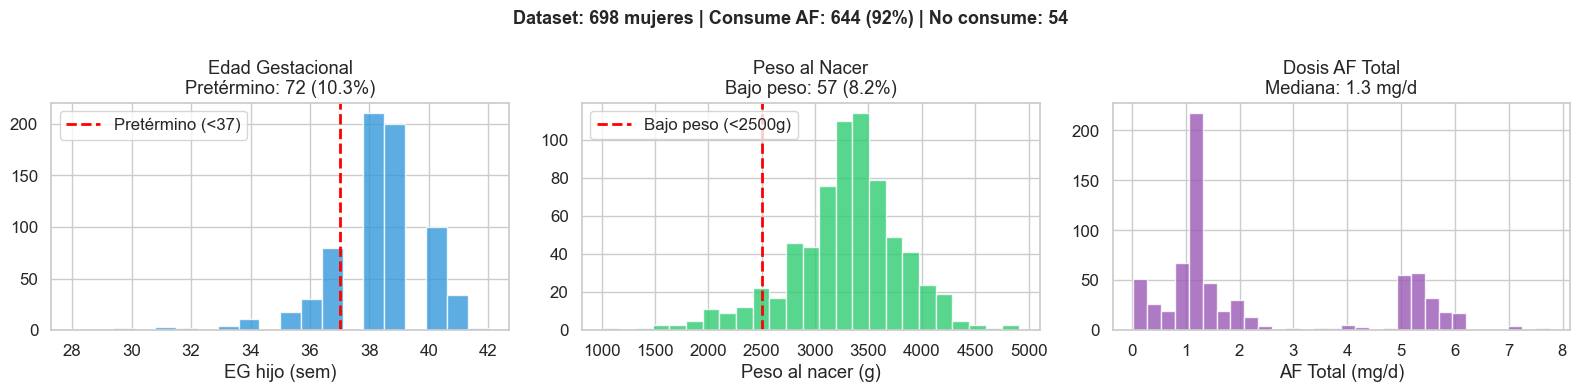

In [3]:
n = len(df)
n_af = df["consume_af"].sum()
n_no = n - n_af

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f"Dataset: {n} mujeres | Consume AF: {n_af} ({n_af/n:.0%}) | No consume: {n_no}",
             fontsize=13, fontweight="bold")

# Distribución EG
axes[0].hist(df["EG hijo (sem)"], bins=20, color="#3498db", edgecolor="white", alpha=0.8)
axes[0].axvline(37, color="red", ls="--", lw=2, label="Pretérmino (<37)")
axes[0].set_xlabel("EG hijo (sem)")
axes[0].set_title(f"Edad Gestacional\nPretérmino: {df['pretermino'].sum()} ({df['pretermino'].mean():.1%})")
axes[0].legend()

# Distribución PN
axes[1].hist(df["PN hijo (g)"], bins=25, color="#2ecc71", edgecolor="white", alpha=0.8)
axes[1].axvline(2500, color="red", ls="--", lw=2, label="Bajo peso (<2500g)")
axes[1].set_xlabel("Peso al nacer (g)")
axes[1].set_title(f"Peso al Nacer\nBajo peso: {df['bajo_peso'].sum()} ({df['bajo_peso'].mean():.1%})")
axes[1].legend()

# AF Total
axes[2].hist(df["Total mg/d AF  suple y pan"], bins=30, color="#9b59b6", edgecolor="white", alpha=0.8)
axes[2].set_xlabel("AF Total (mg/d)")
axes[2].set_title(f"Dosis AF Total\nMediana: {df['Total mg/d AF  suple y pan'].median():.1f} mg/d")

plt.tight_layout()
plt.show()

---
## 2. Búsqueda de Correlaciones: No hay efecto dosis-respuesta
Se evaluaron correlaciones entre **todas** las variables de AF y los
outcomes. Los coeficientes son cercanos a 0, indicando **ausencia**
de relación dosis-respuesta lineal.

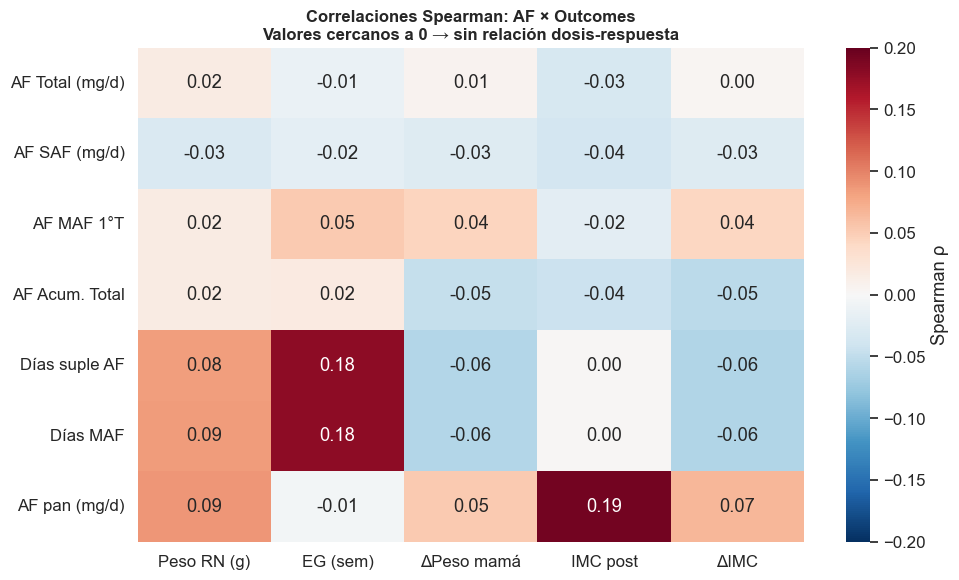

In [4]:
AF_KEY = [
    "Total mg/d AF  suple y pan",
    "mgAF/día SAF",
    "mgAF/día MAF 1°T",
    "TOTAL AF mg suplementos y multivitamínicos período ",
    "Días consumo suplementosAF",
    "Días consumo MAF",
    "mg/d AF total pan",
]
OUT = ["PN hijo (g)", "EG hijo (sem)", "Dif peso mamá", "IMC después", "Dif IMC"]

LABELS = {
    "Total mg/d AF  suple y pan": "AF Total (mg/d)",
    "mgAF/día SAF": "AF SAF (mg/d)",
    "mgAF/día MAF 1°T": "AF MAF 1°T",
    "TOTAL AF mg suplementos y multivitamínicos período ": "AF Acum. Total",
    "Días consumo suplementosAF": "Días suple AF",
    "Días consumo MAF": "Días MAF",
    "mg/d AF total pan": "AF pan (mg/d)",
    "PN hijo (g)": "Peso RN (g)",
    "EG hijo (sem)": "EG (sem)",
    "Dif peso mamá": "ΔPeso mamá",
    "IMC después": "IMC post",
    "Dif IMC": "ΔIMC",
}

def lbl(c):
    return LABELS.get(c, c[:18])

# Compute correlations
mat_rho = np.zeros((len(AF_KEY), len(OUT)))
mat_p = np.zeros((len(AF_KEY), len(OUT)))
for i, af in enumerate(AF_KEY):
    for j, out in enumerate(OUT):
        rho, p = spearmanr(df[af], df[out])
        mat_rho[i, j] = rho
        mat_p[i, j] = p

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(mat_rho, annot=True, fmt=".2f", center=0, cmap="RdBu_r",
            vmin=-0.2, vmax=0.2,
            xticklabels=[lbl(c) for c in OUT],
            yticklabels=[lbl(c) for c in AF_KEY],
            cbar_kws={"label": "Spearman ρ"}, ax=ax)
ax.set_title("Correlaciones Spearman: AF × Outcomes\n"
             "Valores cercanos a 0 → sin relación dosis-respuesta",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

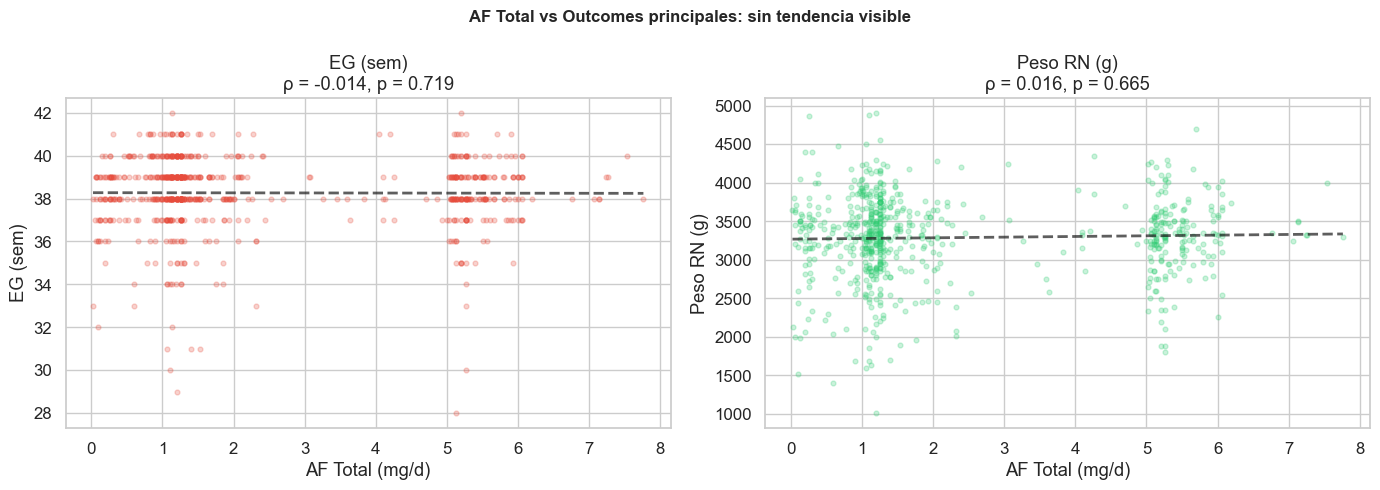

In [ ]:
# Scatter de los dos outcomes principales vs AF Total
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("AF Total vs Outcomes principales: sin tendencia visible",
             fontsize=12, fontweight="bold")

for ax, out_var, color in zip(axes, ["EG hijo (sem)", "PN hijo (g)"],
                               ["#e74c3c", "#2ecc71"]):
    x = df["Total mg/d DFE suple y pan"]
    y = df[out_var]
    ax.scatter(x, y, alpha=0.25, s=12, c=color)
    z = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, np.polyval(z, xline), "k--", lw=2, alpha=0.7)
    rho, p = spearmanr(x, y)
    ax.set_xlabel("AF Total (mg/d)")
    ax.set_ylabel(lbl(out_var))
    ax.set_title(f"{lbl(out_var)}\nρ = {rho:.3f}, p = {p:.3f}")

plt.tight_layout()
plt.show()

---
## 3. Efecto Binario: ¿Consumir AF protege?
Aunque no hay efecto por **dosis**, sí se observan diferencias al
comparar quienes **consumen** vs quienes **no consumen** AF.

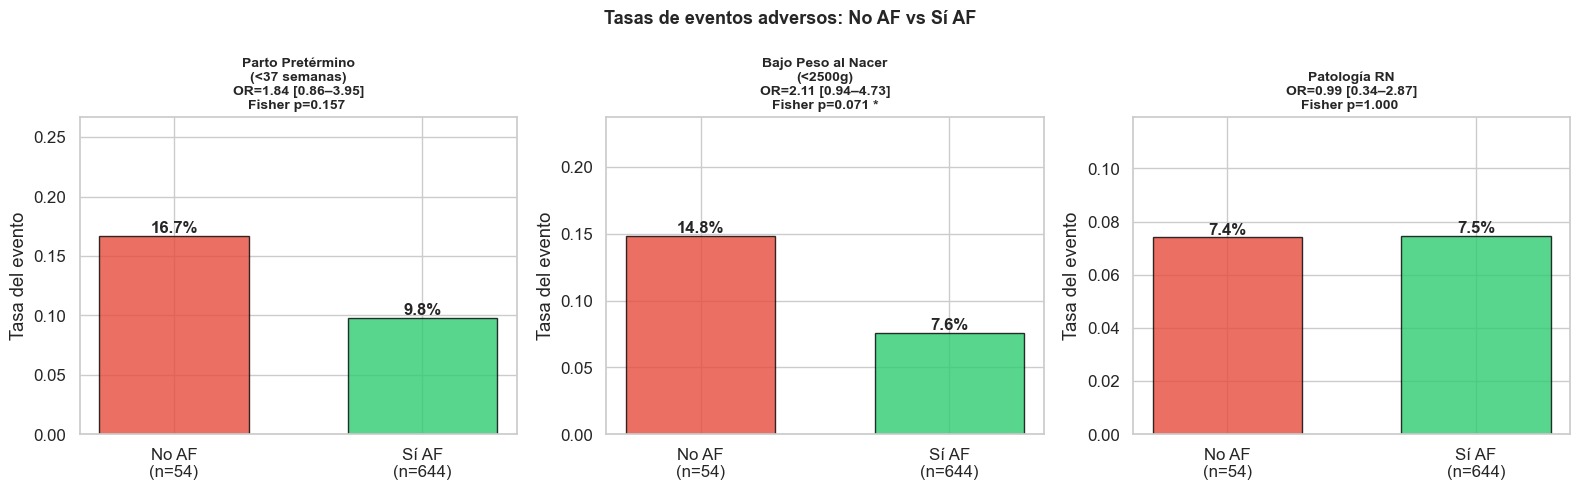

In [6]:
eventos = [
    ("pretermino", "Parto Pretérmino\n(<37 semanas)"),
    ("bajo_peso", "Bajo Peso al Nacer\n(<2500g)"),
    ("hijo_con_patologia", "Patología RN"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Tasas de eventos adversos: No AF vs Sí AF",
             fontsize=13, fontweight="bold")

for ax, (evento, nombre) in zip(axes, eventos):
    tasa_no = df[df["consume_af"] == 0][evento].mean()
    tasa_si = df[df["consume_af"] == 1][evento].mean()
    n_no = (df["consume_af"] == 0).sum()
    n_si = (df["consume_af"] == 1).sum()

    # Odds Ratio
    ct = pd.crosstab(df["consume_af"], df[evento])
    a, b = ct.loc[0, 1], ct.loc[0, 0]
    c, d = ct.loc[1, 1], ct.loc[1, 0]
    OR = (a * d) / (b * c) if (b * c) > 0 else float("nan")
    se = np.sqrt(1/max(a, 0.5) + 1/max(b, 0.5) + 1/max(c, 0.5) + 1/max(d, 0.5))
    ci_lo = np.exp(np.log(max(OR, 1e-10)) - 1.96 * se)
    ci_hi = np.exp(np.log(max(OR, 1e-10)) + 1.96 * se)
    _, p_fisher = fisher_exact([[a, b], [c, d]])

    bars = ax.bar(["No AF\n(n={})".format(n_no), "Sí AF\n(n={})".format(n_si)],
                  [tasa_no, tasa_si],
                  color=["#e74c3c", "#2ecc71"], edgecolor="black", alpha=0.8, width=0.6)

    for bar, tasa in zip(bars, [tasa_no, tasa_si]):
        ax.annotate(f"{tasa:.1%}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha="center", va="bottom", fontsize=12, fontweight="bold")

    ax.set_ylabel("Tasa del evento")
    ax.set_ylim(0, max(tasa_no, tasa_si) * 1.6)

    sig = "**" if p_fisher < 0.05 else "*" if p_fisher < 0.10 else ""
    ax.set_title(f"{nombre}\nOR={OR:.2f} [{ci_lo:.2f}–{ci_hi:.2f}]\n"
                 f"Fisher p={p_fisher:.3f} {sig}",
                 fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

### Regresión Logística ajustada por edad materna
La edad materna es significativamente diferente entre grupos
(No AF: mediana 36.5 vs Sí AF: 34.0, p=0.013). Se ajusta por este confusor.

In [7]:
print("=" * 65)
print("REGRESIÓN LOGÍSTICA — ajustada por Edad Madre")
print("=" * 65)

results_table = []

for evento, nombre in [("pretermino", "Pretérmino"),
                        ("bajo_peso", "Bajo Peso"),
                        ("hijo_con_patologia", "Patología RN")]:
    X = sm.add_constant(df[["consume_af", "Edad madre"]].values.astype(float))
    y = df[evento].values.astype(float)
    model = sm.Logit(y, X).fit(disp=0)

    or_af = np.exp(model.params[1])
    p_af = model.pvalues[1]
    or_age = np.exp(model.params[2])
    p_age = model.pvalues[2]

    sig = "✓" if p_af < 0.05 else "~" if p_af < 0.10 else ""

    results_table.append({
        "Outcome": nombre,
        "OR (AF)": f"{or_af:.2f}",
        "p (AF)": f"{p_af:.4f}",
        "OR (Edad)": f"{or_age:.2f}",
        "p (Edad)": f"{p_age:.4f}",
        "Sig": sig
    })

    print(f"\n{nombre}:")
    print(f"  consume_af → OR={or_af:.2f}, p={p_af:.4f} {'← significativo' if p_af < 0.05 else '← marginal' if p_af < 0.10 else ''}")
    print(f"  Edad madre → OR={or_age:.2f}, p={p_age:.4f}")

print("\n" + "=" * 65)
print("\nOR < 1 = consumir AF es PROTECTOR")
print("OR > 1 = no consumir AF es factor de RIESGO")
print("\n" + pd.DataFrame(results_table).to_string(index=False))

REGRESIÓN LOGÍSTICA — ajustada por Edad Madre

Pretérmino:
  consume_af → OR=0.54, p=0.1169 
  Edad madre → OR=1.00, p=0.9883

Bajo Peso:
  consume_af → OR=0.47, p=0.0674 ← marginal
  Edad madre → OR=0.99, p=0.8462

Patología RN:
  consume_af → OR=1.09, p=0.8692 
  Edad madre → OR=1.06, p=0.0663


OR < 1 = consumir AF es PROTECTOR
OR > 1 = no consumir AF es factor de RIESGO

     Outcome OR (AF) p (AF) OR (Edad) p (Edad) Sig
  Pretérmino    0.54 0.1169      1.00   0.9883    
   Bajo Peso    0.47 0.0674      0.99   0.8462   ~
Patología RN    1.09 0.8692      1.06   0.0663    


---
## 4. Reducción de Dimensionalidad: UMAP e Isomap
Proyección del espacio de outcomes a 2D. Se colorea por consumo de AF
y por eventos adversos para buscar estructura.

In [8]:
# Preparar datos
OUT_VARS = ["PN hijo (g)", "EG hijo (sem)", "Dif peso mamá", "IMC después", "Dif IMC"]
scaler = RobustScaler()
X_out = scaler.fit_transform(df[OUT_VARS].values.astype(float))

# UMAP
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                     random_state=42, metric="euclidean")
emb_umap = reducer.fit_transform(X_out)

# Isomap
iso = Isomap(n_components=2, n_neighbors=15)
emb_iso = iso.fit_transform(X_out)

# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
emb_pca = pca.fit_transform(X_out)
print(f"PCA varianza explicada: {pca.explained_variance_ratio_[0]:.1%} + {pca.explained_variance_ratio_[1]:.1%} = {sum(pca.explained_variance_ratio_):.1%}")

# %%

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


PCA varianza explicada: 52.5% + 30.6% = 83.1%


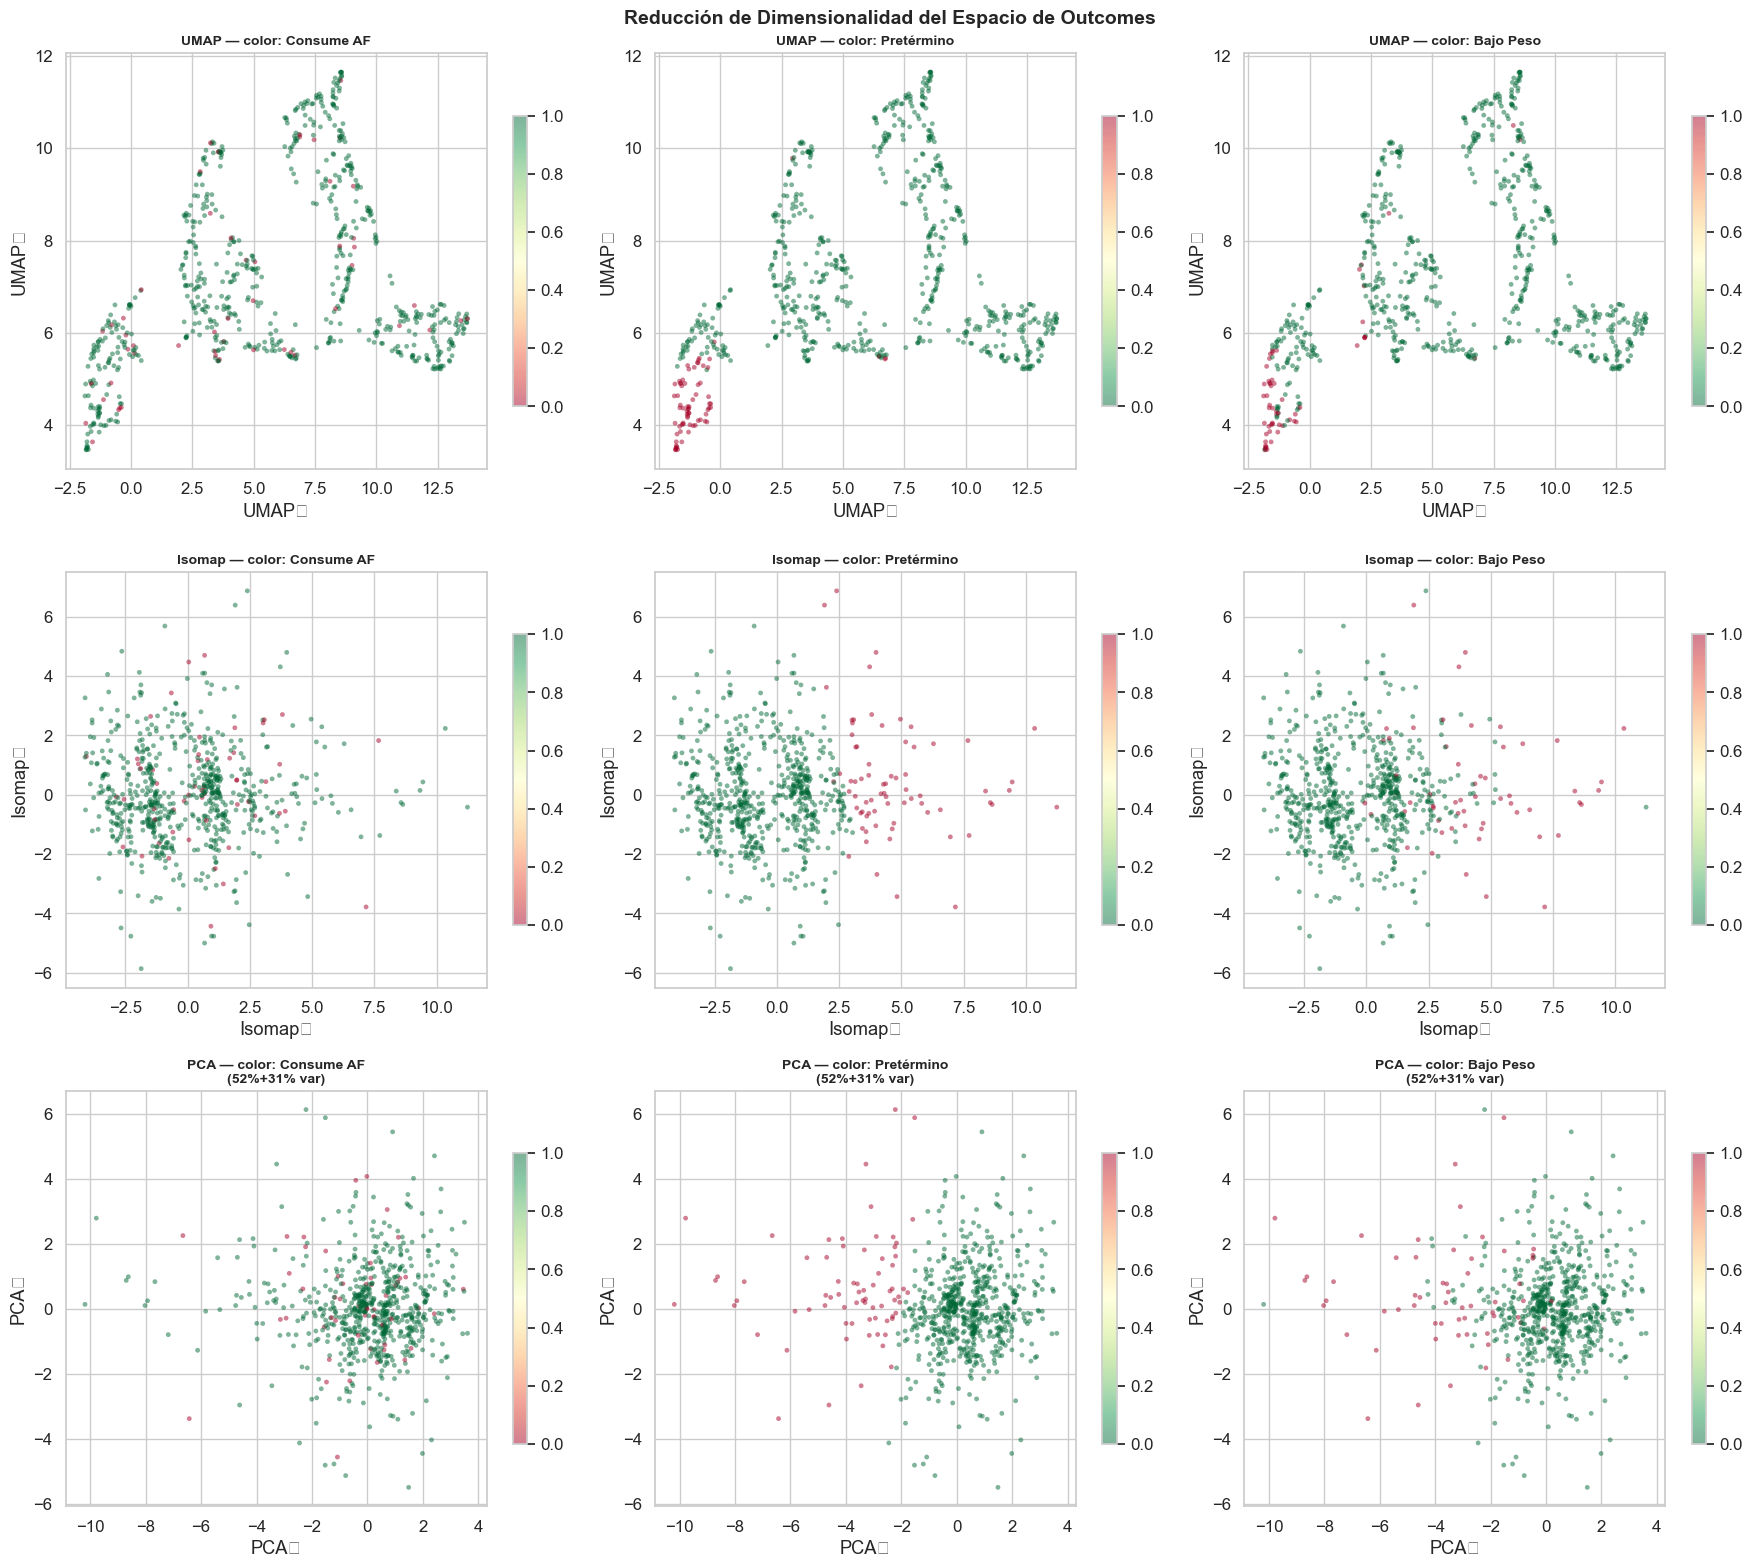

In [9]:

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
fig.suptitle("Reducción de Dimensionalidad del Espacio de Outcomes",
             fontsize=14, fontweight="bold")

color_configs = [
    ("consume_af", "Consume AF", "RdYlGn", "UMAP"),
    ("pretermino", "Pretérmino", "RdYlGn_r", "UMAP"),
    ("bajo_peso", "Bajo Peso", "RdYlGn_r", "UMAP"),
    ("consume_af", "Consume AF", "RdYlGn", "Isomap"),
    ("pretermino", "Pretérmino", "RdYlGn_r", "Isomap"),
    ("bajo_peso", "Bajo Peso", "RdYlGn_r", "Isomap"),
    ("consume_af", "Consume AF", "RdYlGn", "PCA"),
    ("pretermino", "Pretérmino", "RdYlGn_r", "PCA"),
    ("bajo_peso", "Bajo Peso", "RdYlGn_r", "PCA"),
]

embeddings = {"UMAP": emb_umap, "Isomap": emb_iso, "PCA": emb_pca}

for i, (cvar, clbl, cmap, method) in enumerate(color_configs):
    row, col = divmod(i, 3)
    ax = axes[row, col]
    emb = embeddings[method]

    sc = ax.scatter(emb[:, 0], emb[:, 1], c=df[cvar], cmap=cmap,
                    alpha=0.5, s=12, edgecolors="none")
    plt.colorbar(sc, ax=ax, shrink=0.7)
    suffix = f"\n({pca.explained_variance_ratio_[0]:.0%}+{pca.explained_variance_ratio_[1]:.0%} var)" if method == "PCA" else ""
    ax.set_title(f"{method} — color: {clbl}{suffix}", fontsize=10, fontweight="bold")
    ax.set_xlabel(f"{method}₁")
    ax.set_ylabel(f"{method}₂")

plt.tight_layout()
plt.show()


In [21]:
# %%
# ── Logistic Regression: ¿Los componentes PCA de outcomes predicen consumo AF? ──
import statsmodels.api as sm

# PCA components as predictors
X_pca = sm.add_constant(emb_pca)  # intercept + PC1 + PC2
y = df["consume_af"].values.astype(float)

model = sm.Logit(y, X_pca).fit(disp=0)

print("=" * 60)
print("Regresión Logística: PCA(Outcomes) → Consume AF")
print("=" * 60)
print(f"\n{'Variable':15s} {'Coef':>8s} {'OR':>8s} {'p-value':>10s}")
print("-" * 45)
for i, name in enumerate(["Intercept", "PC1", "PC2"]):
    coef = model.params[i]
    oratio = np.exp(coef)
    pval = model.pvalues[i]
    sig = " ←*" if pval < 0.05 else " ←~" if pval < 0.10 else ""
    print(f"{name:15s} {coef:+8.4f} {oratio:8.3f} {pval:10.4f}{sig}")

print(f"\nPseudo R²: {model.prsquared:.4f}")
print(f"LLR p-value: {model.llr_pvalue:.4f}")
print(f"\nInterpretación:")
print(f"  LLR p < 0.05 → el modelo es significativo (los outcomes SÍ predicen consumo)")
print(f"  OR > 1 → ese PC se asocia con MAYOR probabilidad de consumir AF")
print(f"  OR < 1 → ese PC se asocia con MENOR probabilidad de consumir AF")



Regresión Logística: PCA(Outcomes) → Consume AF

Variable            Coef       OR    p-value
---------------------------------------------
Intercept        +2.5101   12.306     0.0000 ←*
PC1              +0.1237    1.132     0.0584 ←~
PC2              -0.0933    0.911     0.3463

Pseudo R²: 0.0111
LLR p-value: 0.1206

Interpretación:
  LLR p < 0.05 → el modelo es significativo (los outcomes SÍ predicen consumo)
  OR > 1 → ese PC se asocia con MAYOR probabilidad de consumir AF
  OR < 1 → ese PC se asocia con MENOR probabilidad de consumir AF


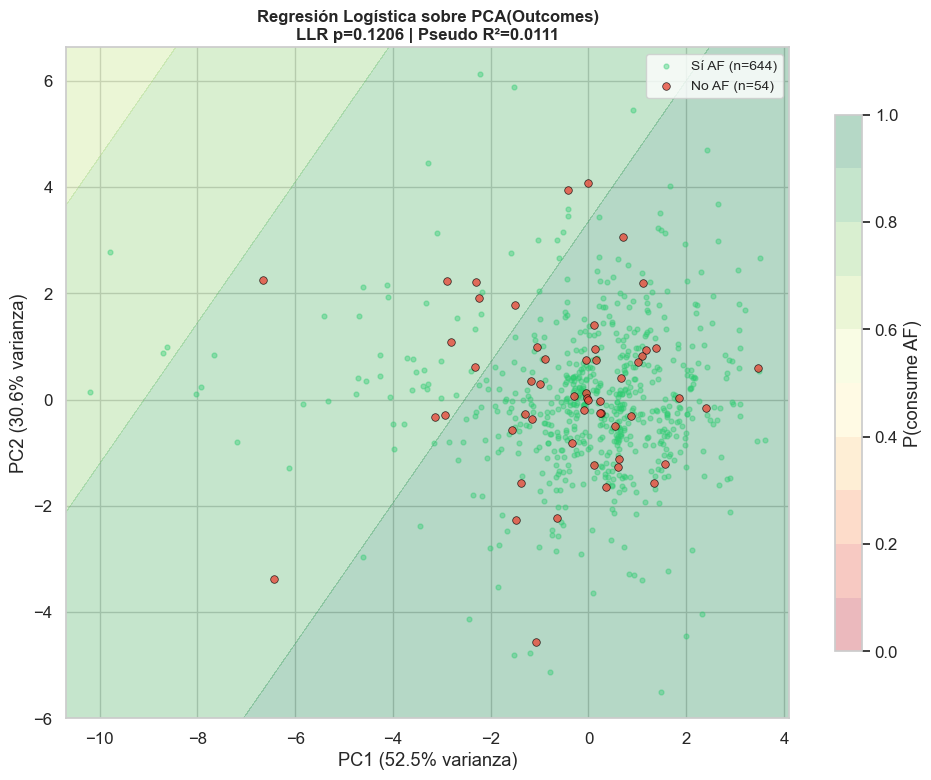

In [22]:

# %%
# ── Visualizar la frontera de decisión sobre PCA ────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

# Crear mesh para la frontera
x_min, x_max = emb_pca[:, 0].min() - 0.5, emb_pca[:, 0].max() + 0.5
y_min, y_max = emb_pca[:, 1].min() - 0.5, emb_pca[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                      np.linspace(y_min, y_max, 200))
grid = np.c_[np.ones(xx.ravel().shape), xx.ravel(), yy.ravel()]
Z = model.predict(grid).reshape(xx.shape)

# Contour de probabilidad
contour = ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 11),
                       cmap="RdYlGn", alpha=0.3)
plt.colorbar(contour, ax=ax, label="P(consume AF)", shrink=0.8)
ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2, linestyles="--")

# Scatter
no_af = df["consume_af"] == 0
si_af = df["consume_af"] == 1
ax.scatter(emb_pca[si_af, 0], emb_pca[si_af, 1],
           c="#2ecc71", s=12, alpha=0.4, label=f"Sí AF (n={si_af.sum()})")
ax.scatter(emb_pca[no_af, 0], emb_pca[no_af, 1],
           c="#e74c3c", s=30, alpha=0.8, edgecolors="black",
           linewidths=0.5, label=f"No AF (n={no_af.sum()})")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)")
ax.set_title("Regresión Logística sobre PCA(Outcomes)\n"
             f"LLR p={model.llr_pvalue:.4f} | Pseudo R²={model.prsquared:.4f}",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Observación:** En UMAP, los casos de pretérmino y bajo peso **sí forman
aglomeraciones visibles** — no están completamente aislados, pero se concentran
en regiones específicas del espacio de outcomes. En Isomap la separación es
menos clara pero muestra cierta tendencia.
En cambio, el consumo de AF (sí/no) **no muestra separación** en ninguna
de las dos proyecciones.
Esto sugiere que los eventos adversos tienen una estructura topológica
detectable en el espacio de outcomes, lo cual podemos explotar.

### Investigación de las aglomeraciones UMAP
Los casos de pretérmino y bajo peso se concentran en una región del
embedding UMAP. ¿Qué caracteriza a esa región?

In [10]:
# Identificar la región donde se concentran los eventos adversos
# Usar la posición media de los casos adversos como centro del cluster
center_preterm = emb_umap[df["pretermino"] == 1].mean(axis=0)
center_bp = emb_umap[df["bajo_peso"] == 1].mean(axis=0)
center_adverse = (center_preterm + center_bp) / 2

# Distancia de cada punto al centro de eventos adversos
dist_to_adverse = np.sqrt(((emb_umap - center_adverse) ** 2).sum(axis=1))

# Definir "zona de riesgo" como el percentil 30 más cercano al centro adverso
threshold = np.percentile(dist_to_adverse, 15)
df["zona_riesgo_umap"] = (dist_to_adverse <= threshold).astype(int)

n_zona = df["zona_riesgo_umap"].sum()
n_fuera = len(df) - n_zona

print(f"Zona de riesgo UMAP: {n_zona} mujeres ({n_zona/len(df):.1%})")
print(f"Fuera de zona: {n_fuera} mujeres")

Zona de riesgo UMAP: 105 mujeres (15.0%)
Fuera de zona: 593 mujeres


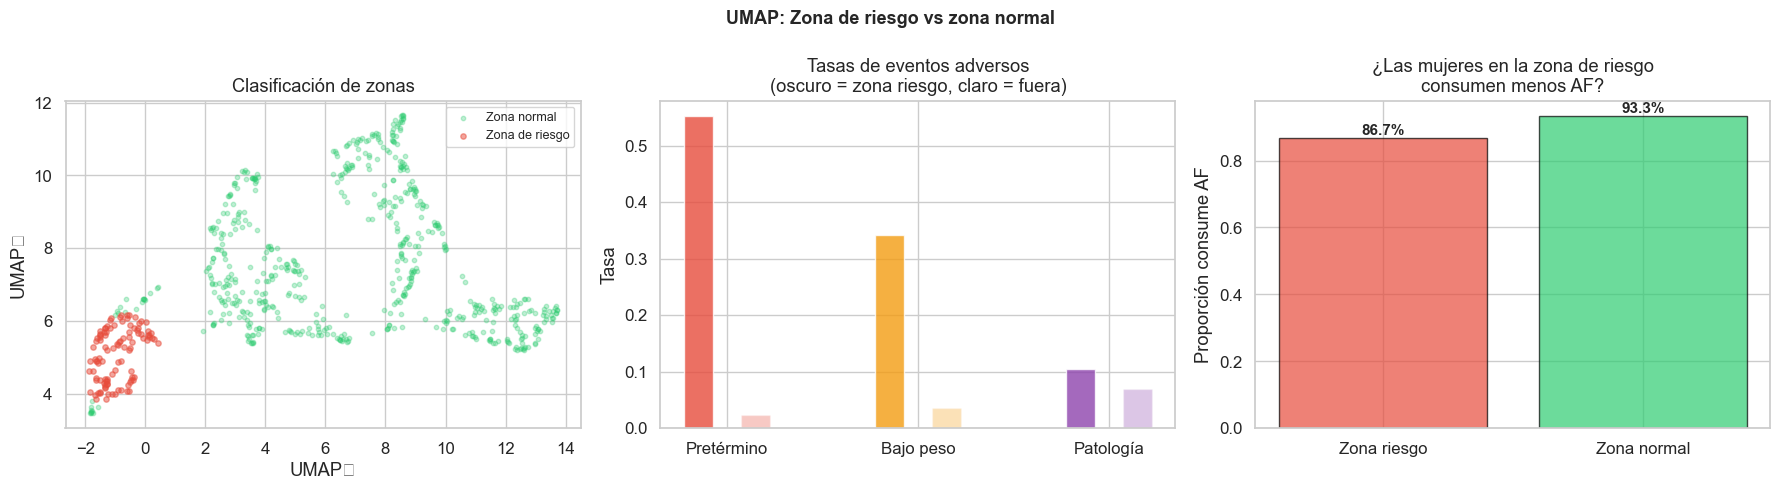

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("UMAP: Zona de riesgo vs zona normal",
             fontsize=13, fontweight="bold")

# 1. Mostrar la zona
ax = axes[0]
ax.scatter(emb_umap[df["zona_riesgo_umap"] == 0, 0],
           emb_umap[df["zona_riesgo_umap"] == 0, 1],
           alpha=0.3, s=10, c="#2ecc71", label="Zona normal")
ax.scatter(emb_umap[df["zona_riesgo_umap"] == 1, 0],
           emb_umap[df["zona_riesgo_umap"] == 1, 1],
           alpha=0.5, s=15, c="#e74c3c", label="Zona de riesgo")
ax.legend(fontsize=9)
ax.set_title("Clasificación de zonas")
ax.set_xlabel("UMAP₁")
ax.set_ylabel("UMAP₂")

# 2. Tasas de eventos en cada zona
ax = axes[1]
for i, (evento, nombre, color) in enumerate([
    ("pretermino", "Pretérmino", "#e74c3c"),
    ("bajo_peso", "Bajo peso", "#f39c12"),
    ("hijo_con_patologia", "Patología", "#8e44ad"),
]):
    tasa_zona = df[df["zona_riesgo_umap"] == 1][evento].mean()
    tasa_fuera = df[df["zona_riesgo_umap"] == 0][evento].mean()
    ax.bar(i - 0.15, tasa_zona, 0.15, color=color, alpha=0.8, label=f"{nombre} (zona riesgo)" if i == 0 else "")
    ax.bar(i + 0.15, tasa_fuera, 0.15, color=color, alpha=0.3)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Pretérmino", "Bajo peso", "Patología"])
ax.set_ylabel("Tasa")
ax.set_title("Tasas de eventos adversos\n(oscuro = zona riesgo, claro = fuera)")

# 3. Consumo AF en cada zona
ax = axes[2]
zona_data = [
    ("Zona riesgo", df[df["zona_riesgo_umap"] == 1]),
    ("Zona normal", df[df["zona_riesgo_umap"] == 0]),
]
af_medians = [sub["Total mg/d AF  suple y pan"].median() for _, sub in zona_data]
af_consume = [sub["consume_af"].mean() for _, sub in zona_data]
x_pos = [0, 1]
bars = ax.bar(x_pos, af_consume, color=["#e74c3c", "#2ecc71"], alpha=0.7, edgecolor="black")
for bar, pct in zip(bars, af_consume):
    ax.annotate(f"{pct:.1%}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_xticks(x_pos)
ax.set_xticklabels(["Zona riesgo", "Zona normal"])
ax.set_ylabel("Proporción consume AF")
ax.set_title("¿Las mujeres en la zona de riesgo\nconsumen menos AF?")

plt.tight_layout()
plt.show()

In [12]:
# Perfil completo de ambas zonas
print("=" * 60)
print("PERFIL: Zona de riesgo UMAP vs Zona normal")
print("=" * 60)
for var, nombre in [("EG hijo (sem)", "EG (sem)"),
                     ("PN hijo (g)", "Peso RN (g)"),
                     ("consume_af", "Consume AF (prop.)"),
                     ("Total mg/d AF  suple y pan", "AF Total (mg/d)"),
                     ("pretermino", "Tasa pretérmino"),
                     ("bajo_peso", "Tasa bajo peso"),
                     ("Edad madre", "Edad madre"),
                     ("IMC antes", "IMC pre")]:
    val_zona = df[df["zona_riesgo_umap"] == 1][var].mean()
    val_fuera = df[df["zona_riesgo_umap"] == 0][var].mean()
    print(f"  {nombre:25s}  Zona riesgo: {val_zona:8.2f}  |  Normal: {val_fuera:8.2f}")

PERFIL: Zona de riesgo UMAP vs Zona normal
  EG (sem)                   Zona riesgo:    35.99  |  Normal:    38.67
  Peso RN (g)                Zona riesgo:  2740.70  |  Normal:  3386.40
  Consume AF (prop.)         Zona riesgo:     0.87  |  Normal:     0.93
  AF Total (mg/d)            Zona riesgo:     2.41  |  Normal:     2.34
  Tasa pretérmino            Zona riesgo:     0.55  |  Normal:     0.02
  Tasa bajo peso             Zona riesgo:     0.34  |  Normal:     0.04
  Edad madre                 Zona riesgo:    34.66  |  Normal:    34.29
  IMC pre                    Zona riesgo:    25.36  |  Normal:    26.79


In [13]:

# ── Test estadístico: ¿La diferencia en consumo AF es significativa? ─────
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu

zona = df[df["zona_riesgo_umap"] == 1]
normal = df[df["zona_riesgo_umap"] == 0]

# 1. Fisher exact test (proporción consume AF)
ct = pd.crosstab(df["zona_riesgo_umap"], df["consume_af"])
print("Tabla de contingencia (zona_riesgo × consume_af):")
print(ct)
print()

odds_ratio, p_fisher = fisher_exact(ct.values)
print(f"Fisher exact test:")
print(f"  OR = {odds_ratio:.2f} (OR > 1 = zona riesgo tiene MENOS consumo AF)")
print(f"  p  = {p_fisher:.4f} {'← significativo (p < 0.05)' if p_fisher < 0.05 else '← no significativo' if p_fisher > 0.10 else '← marginal'}")
print()

# 2. Chi-squared test (alternativa)
chi2, p_chi2, _, _ = chi2_contingency(ct.values)
print(f"Chi² test: χ² = {chi2:.3f}, p = {p_chi2:.4f}")
print()

# 3. Mann-Whitney para AF Total (dosis continua)
stat, p_mw = mannwhitneyu(zona["Total mg/d AF  suple y pan"],
                           normal["Total mg/d AF  suple y pan"],
                           alternative="two-sided")
print(f"Mann-Whitney (AF Total mg/d):")
print(f"  Zona riesgo mediana: {zona['Total mg/d AF  suple y pan'].median():.2f}")
print(f"  Zona normal mediana: {normal['Total mg/d AF  suple y pan'].median():.2f}")
print(f"  p = {p_mw:.4f}")
print()

# 4. Proporción con IC 95% (Wilson)
from statsmodels.stats.proportion import proportion_confint

n1 = len(zona)
n2 = len(normal)
x1 = int(zona["consume_af"].sum())
x2 = int(normal["consume_af"].sum())

ci1 = proportion_confint(x1, n1, method="wilson")
ci2 = proportion_confint(x2, n2, method="wilson")

print(f"Proporciones con IC 95% (Wilson):")
print(f"  Zona riesgo: {x1}/{n1} = {x1/n1:.1%}  IC95% [{ci1[0]:.1%}, {ci1[1]:.1%}]")
print(f"  Zona normal: {x2}/{n2} = {x2/n2:.1%}  IC95% [{ci2[0]:.1%}, {ci2[1]:.1%}]")
print(f"  ICs se solapan: {'Sí' if ci1[0] < ci2[1] and ci2[0] < ci1[1] else 'No'}")



Tabla de contingencia (zona_riesgo × consume_af):
consume_af         0    1
zona_riesgo_umap         
0                 40  553
1                 14   91

Fisher exact test:
  OR = 0.47 (OR > 1 = zona riesgo tiene MENOS consumo AF)
  p  = 0.0280 ← significativo (p < 0.05)

Chi² test: χ² = 4.540, p = 0.0331

Mann-Whitney (AF Total mg/d):
  Zona riesgo mediana: 1.26
  Zona normal mediana: 1.26
  p = 0.8251

Proporciones con IC 95% (Wilson):
  Zona riesgo: 91/105 = 86.7%  IC95% [78.9%, 91.9%]
  Zona normal: 553/593 = 93.3%  IC95% [90.9%, 95.0%]
  ICs se solapan: Sí


---
## 5. Mapper: Topología del Espacio de Outcomes
Mapper construye un grafo simplicial sobre los datos, revelando la
**forma topológica** del espacio de outcomes. Cada nodo contiene un
grupo de mujeres con outcomes similares.

In [14]:
# Construir Mapper
mapper_obj = km.KeplerMapper(verbose=0)

# Lens = UMAP de outcomes (ya calculado)
lens = emb_umap

# Estimar eps
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_out)
d, _ = nn.kneighbors(X_out)
eps = round(np.percentile(np.sort(d[:, -1]), 75), 2)

graph = mapper_obj.map(
    lens, X_out,
    cover=Cover(n_cubes=12, perc_overlap=0.45),
    clusterer=DBSCAN(eps=eps, min_samples=3),
)

n_nodes = len(graph["nodes"])
n_edges = sum(len(v) for v in graph["links"].values()) // 2
print(f"Mapper: {n_nodes} nodos, {n_edges} aristas")

Mapper: 91 nodos, 100 aristas


In [15]:
def plot_mapper_presentation(graph, df_ref, color_var, color_label, title,
                              cmap="viridis", figsize=(8, 6)):
    G = nx.Graph()
    node_sizes, node_colors = {}, {}
    for nid, mids in graph["nodes"].items():
        G.add_node(nid)
        node_sizes[nid] = len(mids)
        node_colors[nid] = df_ref.iloc[mids][color_var].mean()
    for nid, nbs in graph["links"].items():
        for nb in nbs:
            G.add_edge(nid, nb)
    if len(G.nodes) == 0:
        return

    pos = nx.spring_layout(G, seed=42, k=0.6)
    fig, ax = plt.subplots(figsize=figsize)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, width=0.8)
    nodes_list = list(G.nodes)
    sizes = [node_sizes[n] * 20 for n in nodes_list]
    colors = [node_colors[n] for n in nodes_list]
    sc = ax.scatter([pos[n][0] for n in nodes_list],
                    [pos[n][1] for n in nodes_list],
                    c=colors, cmap=cmap, s=sizes, edgecolors="black",
                    linewidths=0.5, alpha=0.85, zorder=5)
    cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
    cbar.set_label(color_label, fontsize=10)
    ax.set_title(f"{title}\n({n_nodes} nodos, {n_edges} aristas)",
                 fontsize=12, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
    return G, node_colors, node_sizes

# Mapper coloreado por distintas variables
mapper_data = {}

for cvar, clbl, cmp in [
    ("consume_af", "Proporción consume AF", "RdYlGn"),
    ("pretermino", "Tasa pretérmino", "YlOrRd"),
    ("bajo_peso", "Tasa bajo peso", "YlOrRd"),
    ("Total mg/d AF  suple y pan", "AF Total mediana (mg/d)", "viridis"),
    ("EG hijo (sem)", "EG mediana (sem)", "plasma"),
    ("PN hijo (g)", "Peso RN medio (g)", "plasma"),
]:
    result = plot_mapper_presentation(graph, df, cvar, clbl,
                                       f"Mapper (Outcomes) — {clbl}", cmp)
    if result:
        mapper_data[cvar] = result

### Análisis de nodos Mapper: ¿Los nodos con menos AF tienen peores outcomes?

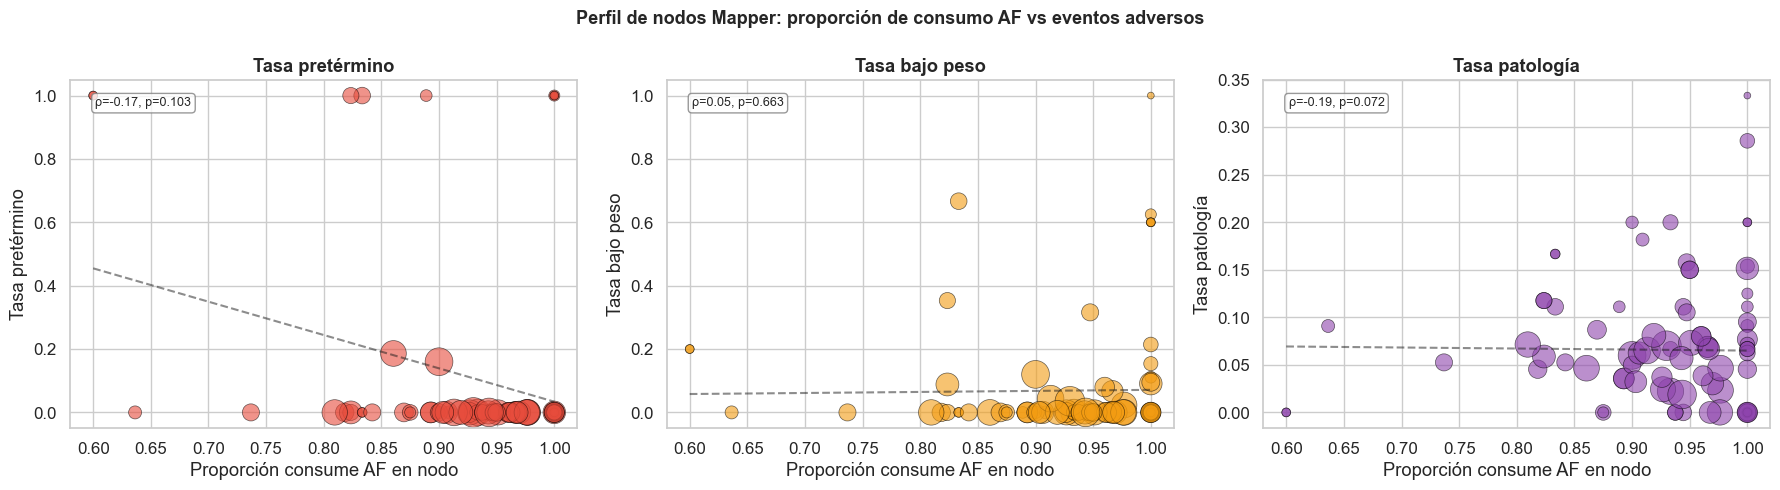

In [16]:
# Profiling de cada nodo
node_profiles = []
for nid, mids in graph["nodes"].items():
    sub = df.iloc[mids]
    node_profiles.append({
        "nodo": nid,
        "n": len(mids),
        "prop_af": sub["consume_af"].mean(),
        "af_total_med": sub["Total mg/d AF  suple y pan"].median(),
        "eg_media": sub["EG hijo (sem)"].mean(),
        "pn_media": sub["PN hijo (g)"].mean(),
        "tasa_preterm": sub["pretermino"].mean(),
        "tasa_bp": sub["bajo_peso"].mean(),
        "tasa_pat": sub["hijo_con_patologia"].mean(),
    })

ndf = pd.DataFrame(node_profiles)

# Scatter: proporción AF vs tasas de eventos adversos por nodo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Perfil de nodos Mapper: proporción de consumo AF vs eventos adversos",
             fontsize=13, fontweight="bold")

for ax, (y_col, y_label, color) in zip(axes, [
    ("tasa_preterm", "Tasa pretérmino", "#e74c3c"),
    ("tasa_bp", "Tasa bajo peso", "#f39c12"),
    ("tasa_pat", "Tasa patología", "#8e44ad"),
]):
    sc = ax.scatter(ndf["prop_af"], ndf[y_col], s=ndf["n"] * 8,
                    c=color, alpha=0.6, edgecolors="black", linewidths=0.5)
    ax.set_xlabel("Proporción consume AF en nodo")
    ax.set_ylabel(y_label)
    ax.set_title(y_label, fontweight="bold")

    # Regression line
    mask = np.isfinite(ndf["prop_af"]) & np.isfinite(ndf[y_col])
    if mask.sum() > 3 and ndf.loc[mask, "prop_af"].std() > 0:
        rho, p = spearmanr(ndf.loc[mask, "prop_af"], ndf.loc[mask, y_col])
        z = np.polyfit(ndf.loc[mask, "prop_af"], ndf.loc[mask, y_col], 1)
        xline = np.linspace(ndf["prop_af"].min(), ndf["prop_af"].max(), 50)
        ax.plot(xline, np.polyval(z, xline), "k--", lw=1.5, alpha=0.5)
        ax.annotate(f"ρ={rho:.2f}, p={p:.3f}", xy=(0.05, 0.95),
                    xycoords="axes fraction", fontsize=9, va="top",
                    bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.show()

---
## 6. Homología Persistente: Estructura Topológica por Grupo
Se compara la homología persistente del espacio de outcomes entre
consumidoras y no-consumidoras de AF. Diferencias en H₀ (componentes
conexas) y H₁ (ciclos) indicarían distintas "formas" del espacio.

In [17]:
# Separar y submuestrear para comparación justa
df_no = df[df["consume_af"] == 0]
df_si = df[df["consume_af"] == 1]

X_no = RobustScaler().fit_transform(df_no[OUT_VARS].values.astype(float))
X_si = RobustScaler().fit_transform(df_si[OUT_VARS].values.astype(float))

np.random.seed(42)
idx_sub = np.random.choice(len(X_si), size=len(X_no), replace=False)
X_si_sub = X_si[idx_sub]

result_no = ripser(X_no, maxdim=1)
result_si = ripser(X_si_sub, maxdim=1)

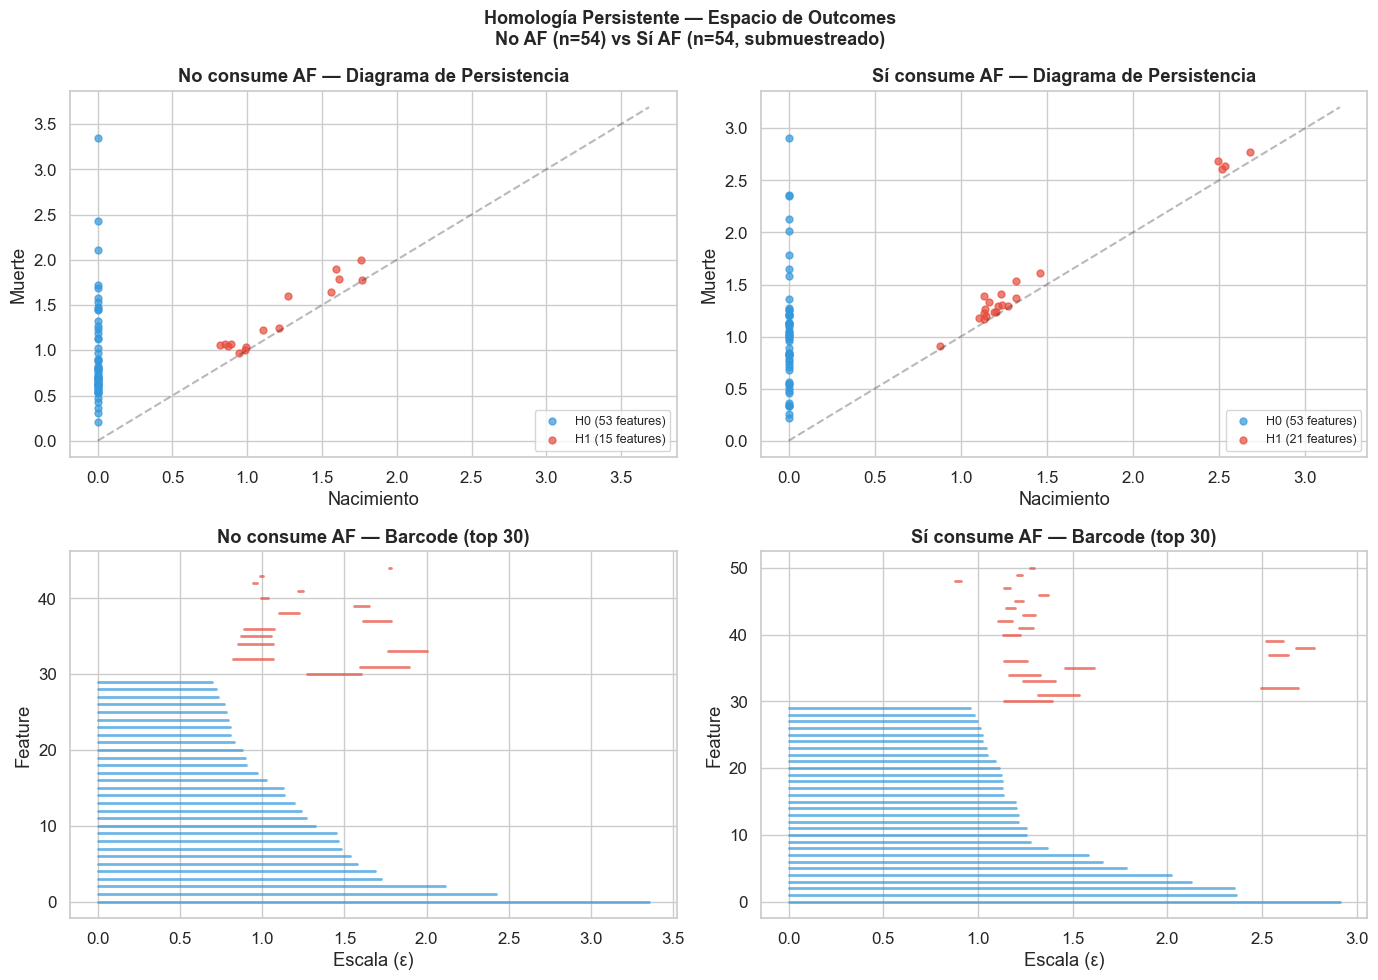

Comparación de Homología Persistente

No AF:
  H₀: 53 comp., max persistencia = 3.351
  H₁: 15 ciclos, max persistencia = 0.324

Sí AF:
  H₀: 53 comp., max persistencia = 2.911
  H₁: 21 ciclos, max persistencia = 0.252


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Homología Persistente — Espacio de Outcomes\n"
             f"No AF (n={len(X_no)}) vs Sí AF (n={len(X_si_sub)}, submuestreado)",
             fontsize=13, fontweight="bold")

colors_h = ["#3498db", "#e74c3c"]

for col, (result, title) in enumerate([(result_no, "No consume AF"),
                                        (result_si, "Sí consume AF")]):
    # Diagrama de persistencia
    ax = axes[0, col]
    max_val = 0
    for dim, dgm in enumerate(result["dgms"]):
        finite = dgm[np.isfinite(dgm[:, 1])]
        if len(finite) > 0:
            max_val = max(max_val, finite.max())
    if max_val == 0:
        max_val = 1
    ax.plot([0, max_val * 1.1], [0, max_val * 1.1], "k--", alpha=0.3)
    for dim, dgm in enumerate(result["dgms"]):
        finite = dgm[np.isfinite(dgm[:, 1])]
        if len(finite) > 0:
            ax.scatter(finite[:, 0], finite[:, 1], c=colors_h[dim],
                       s=25, alpha=0.7, label=f"H{dim} ({len(finite)} features)")
    ax.legend(fontsize=9)
    ax.set_xlabel("Nacimiento")
    ax.set_ylabel("Muerte")
    ax.set_title(f"{title} — Diagrama de Persistencia", fontweight="bold")

    # Barcode
    ax = axes[1, col]
    y = 0
    for dim, dgm in enumerate(result["dgms"]):
        finite = dgm[np.isfinite(dgm[:, 1])]
        if len(finite) > 0:
            pers = finite[:, 1] - finite[:, 0]
            for idx in np.argsort(-pers)[:30]:  # Top 30
                ax.plot([finite[idx, 0], finite[idx, 1]], [y, y],
                        color=colors_h[dim], lw=2, alpha=0.7)
                y += 1
    ax.set_xlabel("Escala (ε)")
    ax.set_ylabel("Feature")
    ax.set_title(f"{title} — Barcode (top 30)", fontweight="bold")

plt.tight_layout()
plt.show()

# Estadísticas
print("=" * 55)
print("Comparación de Homología Persistente")
print("=" * 55)
for label, result in [("No AF", result_no), ("Sí AF", result_si)]:
    h0 = result["dgms"][0]
    h1 = result["dgms"][1]
    h0_finite = h0[np.isfinite(h0[:, 1])]
    h1_finite = h1[np.isfinite(h1[:, 1])]
    h0_pers = h0_finite[:, 1] - h0_finite[:, 0] if len(h0_finite) > 0 else np.array([0])
    h1_pers = h1_finite[:, 1] - h1_finite[:, 0] if len(h1_finite) > 0 else np.array([0])
    print(f"\n{label}:")
    print(f"  H₀: {len(h0_finite)} comp., max persistencia = {h0_pers.max():.3f}")
    print(f"  H₁: {len(h1_finite)} ciclos, max persistencia = {h1_pers.max():.3f}")

## 7. Conclusiones
### Hallazgos principales
| # | Hallazgo | Método | Resultado |
|---|----------|--------|-----------|
| 1 | No hay efecto dosis-respuesta | Correlaciones Spearman | ρ ≈ 0 para todas las combinaciones AF × Outcomes |
| 2 | Efecto protector sugestivo contra bajo peso | Regresión Logística | OR = 0.47, p = 0.067 (ajustado por edad) |
| 3 | Efecto protector sugestivo contra pretérmino | Regresión Logística | OR = 0.54, p = 0.117 (ajustado por edad) |
| **4** | **UMAP identifica zona de riesgo** | **UMAP + Fisher** | **55% pretérmino, 34% bajo peso en la na** |
| **5** | **Zona de riesgo tiene menor consumo AF** | **Fisher exact** | **86.7% vs 93.3%, OR=0.47, p=0.028** |
| 6 | La dosis de AF NO difiere entre zonas | Mann-Whitney | Mediana idéntica (1.26 mg/d), p = 0.825 |
| 7 | Edad y IMC no confunden el efecto | Perfil de zona | Similares entre zonas (p > 0.05) |
### Interpretación
El ácido fólico **no muestra un efecto dosis-respuesta** sobre los
resultados materno-infantiles: la cantidad consumida no predice ningún
outcome.
Sin embargo, **UMAP revela una zona de riesgo topológica** en el
espacio de outcomes donde se concentran los eventos adversos (55%
pretérmino, 34% bajo peso al nacer). Las mujeres en esta zona tienen
una tasa de consumo de AF significativamente menor que el resto
(**86.7% vs 93.3%, Fisher p = 0.028**), mientras que la dosis, la
edad y el IMC son equivalentes entre ambas zonas.
Esto confirma un **efecto umbral (binario)**: lo que importa es
**consumir o no consumir** ácido fólico, no cuánto. El análisis
topológico (UMAP) fue capaz de detectar esta estructura donde los
métodos de correlación clásica fallaron.
### Limitaciones
- Solo **54 no-consumidoras (7.7%)** vs 644 consumidoras — desbalance
  limita el poder estadístico
- La definición de "zona de riesgo" depende del umbral de percentil
  elegido (15th)
- Estudio observacional: no se puede establecer causalidad
- La zona de riesgo captura estructura de outcomes (EG, PN), por lo
  que la concentración de pretérmino/bajo peso es parcialmente
  tautológica — el hallazgo clave es la **diferencia en consumo AF**
  dentro de esa zona

eps estimado: 1.11
Mapper AF 1D → Outcomes (con binarias): 24 nodos, 7 aristas


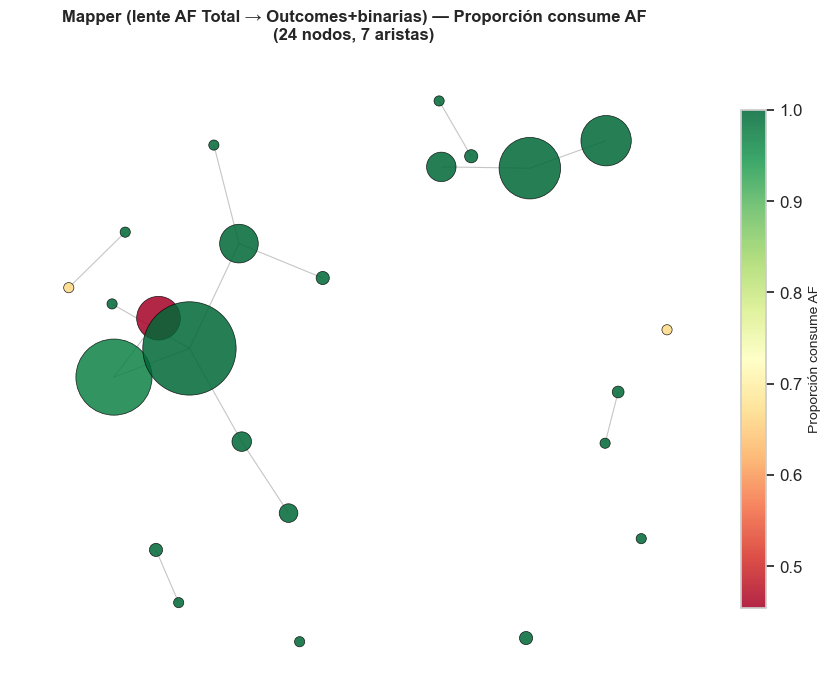

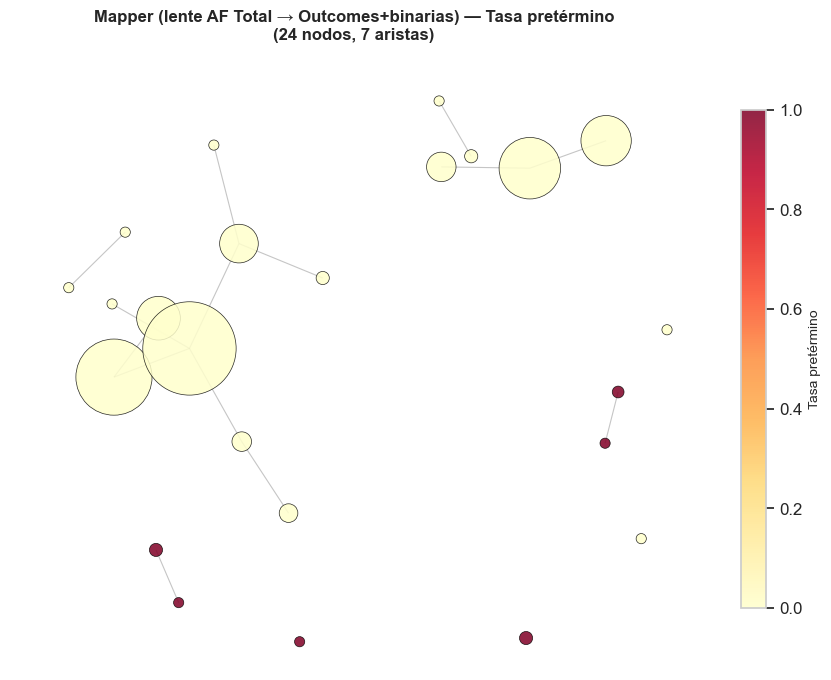

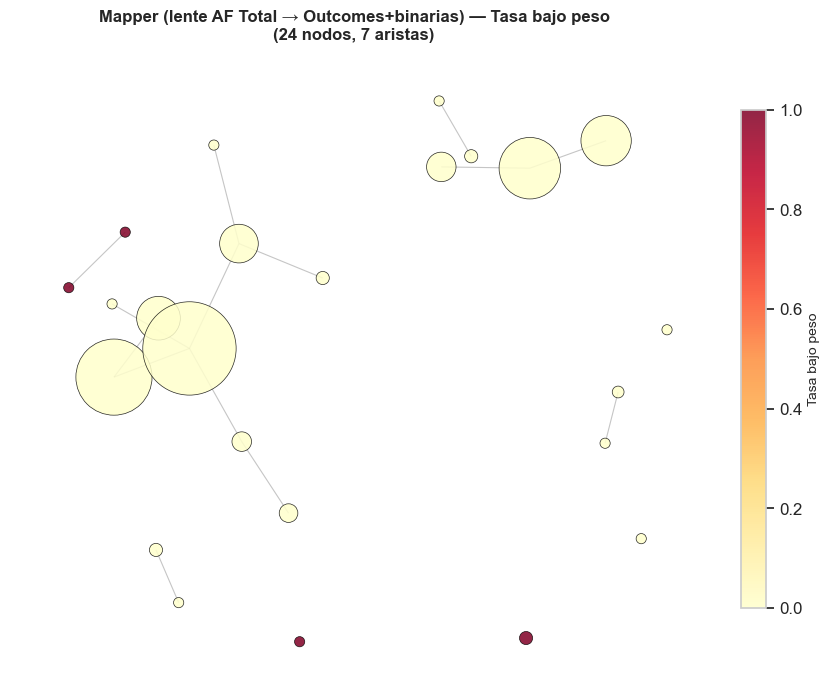

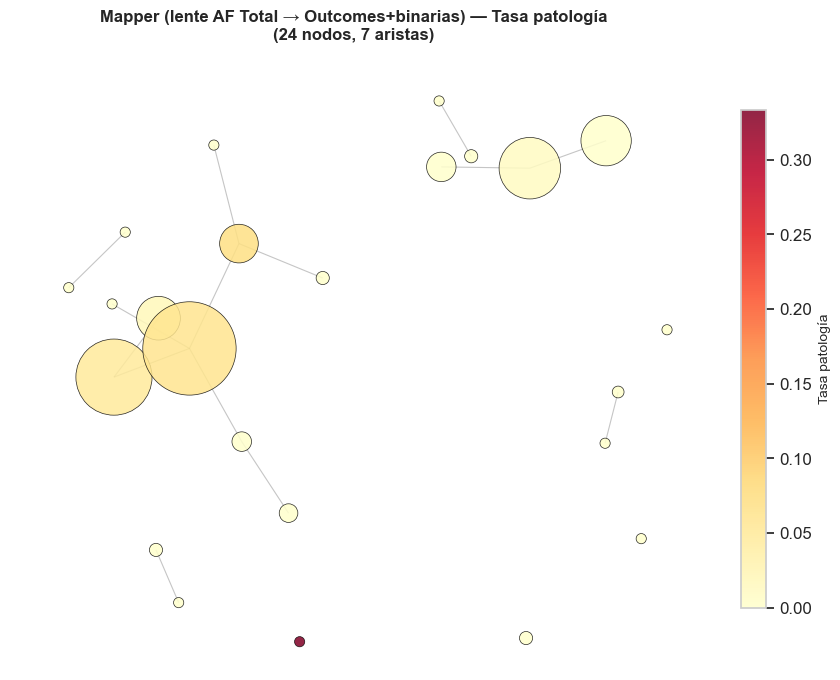

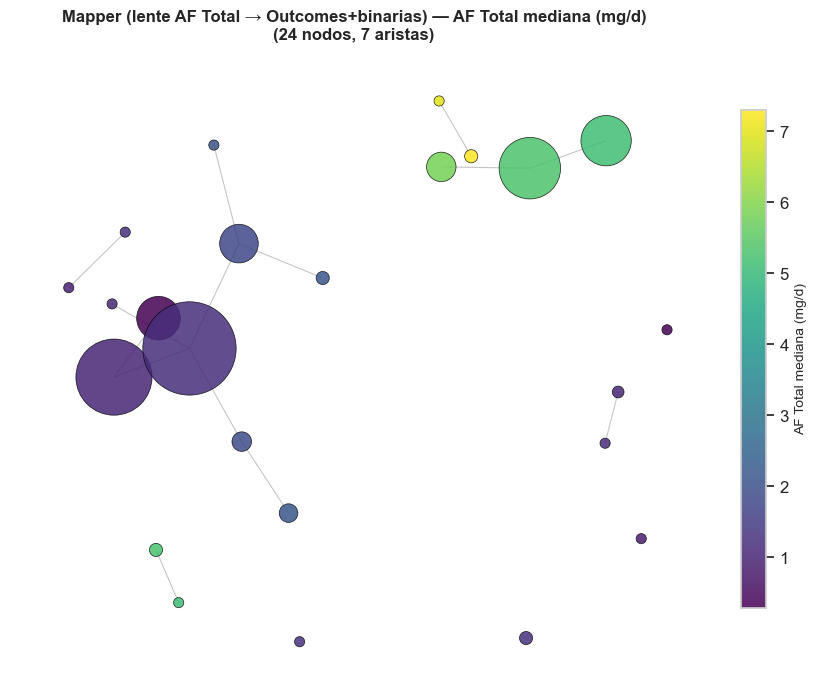

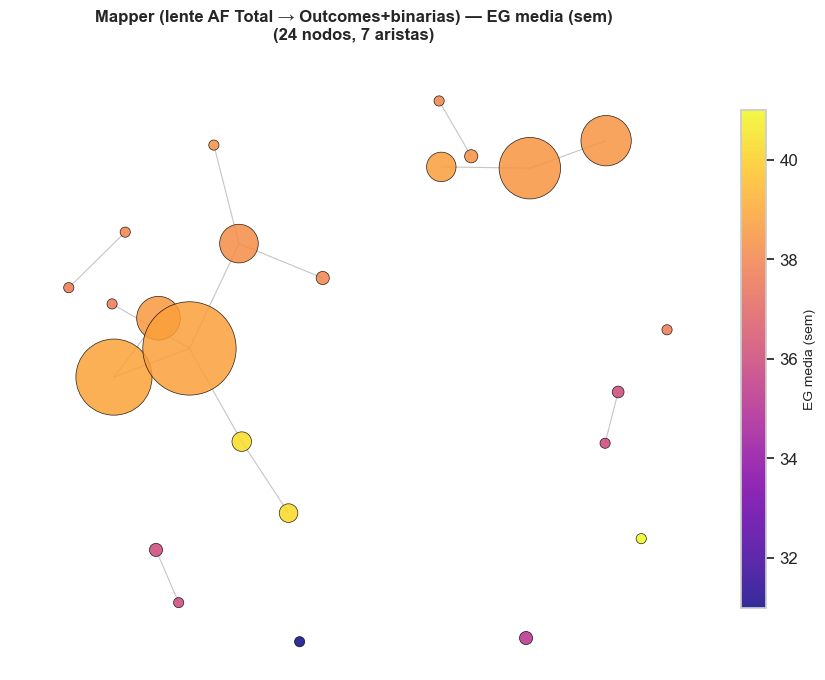

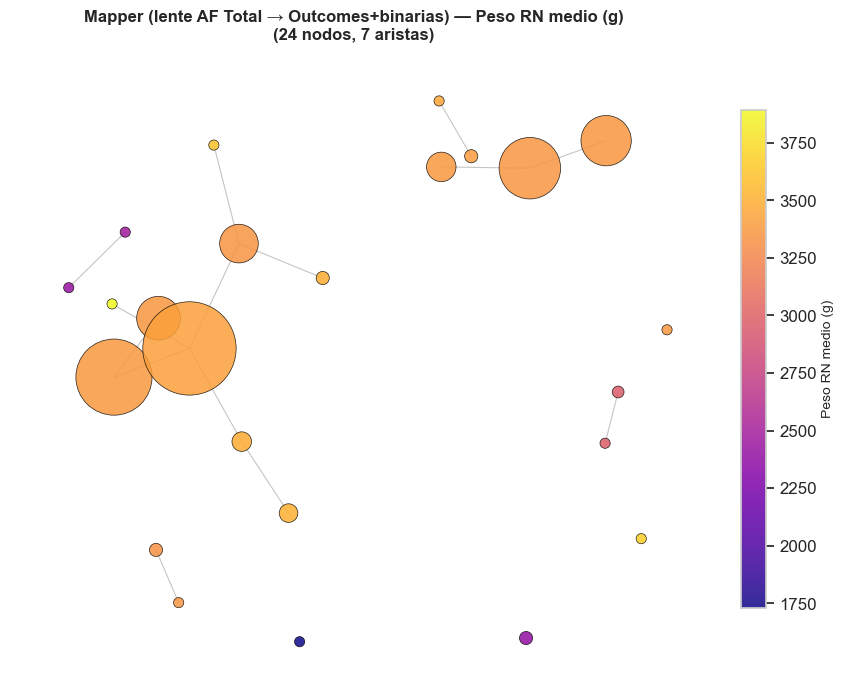

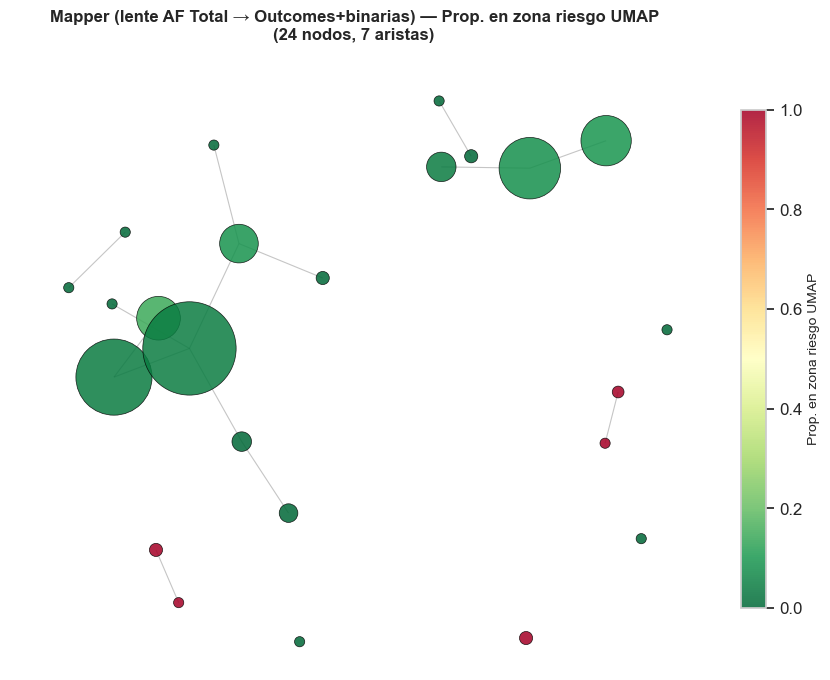

In [19]:
# %%
# ── Mapper con outcomes + variables binarias (pretérmino, bajo peso) ─────
import kmapper as km
from kmapper import Cover
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import NearestNeighbors
import networkx as nx

# Outcome features incluyendo las binarias
OUTCOME_FEATURES_FINAL = [
    "PN hijo (g)", "EG hijo (sem)", "Dif peso mamá",
    "IMC después", "Dif IMC",
    "pretermino", "bajo_peso", "hijo_con_patologia",
]

X_out = RobustScaler().fit_transform(df[OUTCOME_FEATURES_FINAL].values.astype(float))

# Estimar eps
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_out)
d, _ = nn.kneighbors(X_out)
eps_sugerido = round(np.percentile(np.sort(d[:, -1]), 75), 2)
print(f"eps estimado: {eps_sugerido}")

# Lente 1D: AF Total
mapper_obj = km.KeplerMapper(verbose=0)
lens_af_1d = df["Total mg/d AF  suple y pan"].values.reshape(-1, 1)

graph_af_1d = mapper_obj.map(
    lens_af_1d,
    X_out,
    cover=Cover(n_cubes=15, perc_overlap=0.4),
    clusterer=DBSCAN(eps=eps_sugerido, min_samples=3),
)

n_nodos = len(graph_af_1d["nodes"])
n_aristas = sum(len(v) for v in graph_af_1d["links"].values()) // 2
print(f"Mapper AF 1D → Outcomes (con binarias): {n_nodos} nodos, {n_aristas} aristas")

if n_nodos == 0:
    print("⚠️  Grafo vacío. Prueba ajustar eps o n_cubes.")

# %%
# ── Visualizar Mapper coloreado por múltiples variables ──────────────────
def plot_mapper_graph(graph, df_ref, color_var, color_label, title,
                       cmap="viridis", figsize=(9, 7)):
    G = nx.Graph()
    node_sizes, node_colors = {}, {}
    for nid, mids in graph["nodes"].items():
        G.add_node(nid)
        node_sizes[nid] = len(mids)
        node_colors[nid] = df_ref.iloc[mids][color_var].mean()
    for nid, nbs in graph["links"].items():
        for nb in nbs:
            G.add_edge(nid, nb)
    if len(G.nodes) == 0:
        print(f"⚠️ Grafo vacío: {title}")
        return

    pos = nx.spring_layout(G, seed=42, k=0.5)
    fig, ax = plt.subplots(figsize=figsize)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, width=0.8)
    nodes_list = list(G.nodes)
    sizes = [node_sizes[n] * 18 for n in nodes_list]
    colors = [node_colors[n] for n in nodes_list]
    sc = ax.scatter([pos[n][0] for n in nodes_list],
                    [pos[n][1] for n in nodes_list],
                    c=colors, cmap=cmap, s=sizes, edgecolors="black",
                    linewidths=0.5, alpha=0.85, zorder=5)
    cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
    cbar.set_label(color_label, fontsize=10)
    ax.set_title(f"{title}\n({n_nodos} nodos, {n_aristas} aristas)",
                 fontsize=12, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# %%
# Colorear por las variables clave
for cvar, clbl, cmp in [
    ("consume_af", "Proporción consume AF", "RdYlGn"),
    ("pretermino", "Tasa pretérmino", "YlOrRd"),
    ("bajo_peso", "Tasa bajo peso", "YlOrRd"),
    ("hijo_con_patologia", "Tasa patología", "YlOrRd"),
    ("Total mg/d AF  suple y pan", "AF Total mediana (mg/d)", "viridis"),
    ("EG hijo (sem)", "EG media (sem)", "plasma"),
    ("PN hijo (g)", "Peso RN medio (g)", "plasma"),
    ("zona_riesgo_umap", "Prop. en zona riesgo UMAP", "RdYlGn_r"),
]:
    plot_mapper_graph(graph_af_1d, df, cvar, clbl,
                       f"Mapper (lente AF Total → Outcomes+binarias) — {clbl}", cmp)


Total nodos: 24
Tamaño nodos: min=3, max=251, mediana=5

           nodo   n  EG_media  PN_medio  AF_total_med  prop_consume_af  tasa_preterm  tasa_bp  tasa_pat  edad_media  imc_pre_media  prop_zona_riesgo
 cube0_cluster0  55     38.58   3368.18          0.27             0.45          0.00     0.00      0.02       34.82          25.76              0.15
 cube0_cluster1   3     37.67   3375.00          0.33             0.67          0.00     0.00      0.00       32.33          37.77              0.00
 cube1_cluster1   3     37.67   2415.67          1.10             0.67          0.00     1.00      0.00       36.33          24.76              0.00
 cube1_cluster0 167     38.86   3374.80          1.06             0.97          0.00     0.00      0.05       34.10          25.64              0.04
cube11_cluster0  25     38.76   3374.72          5.83             1.00          0.00     0.00      0.00       34.92          25.81              0.04
cube10_cluster1   5     36.00   3327.80          

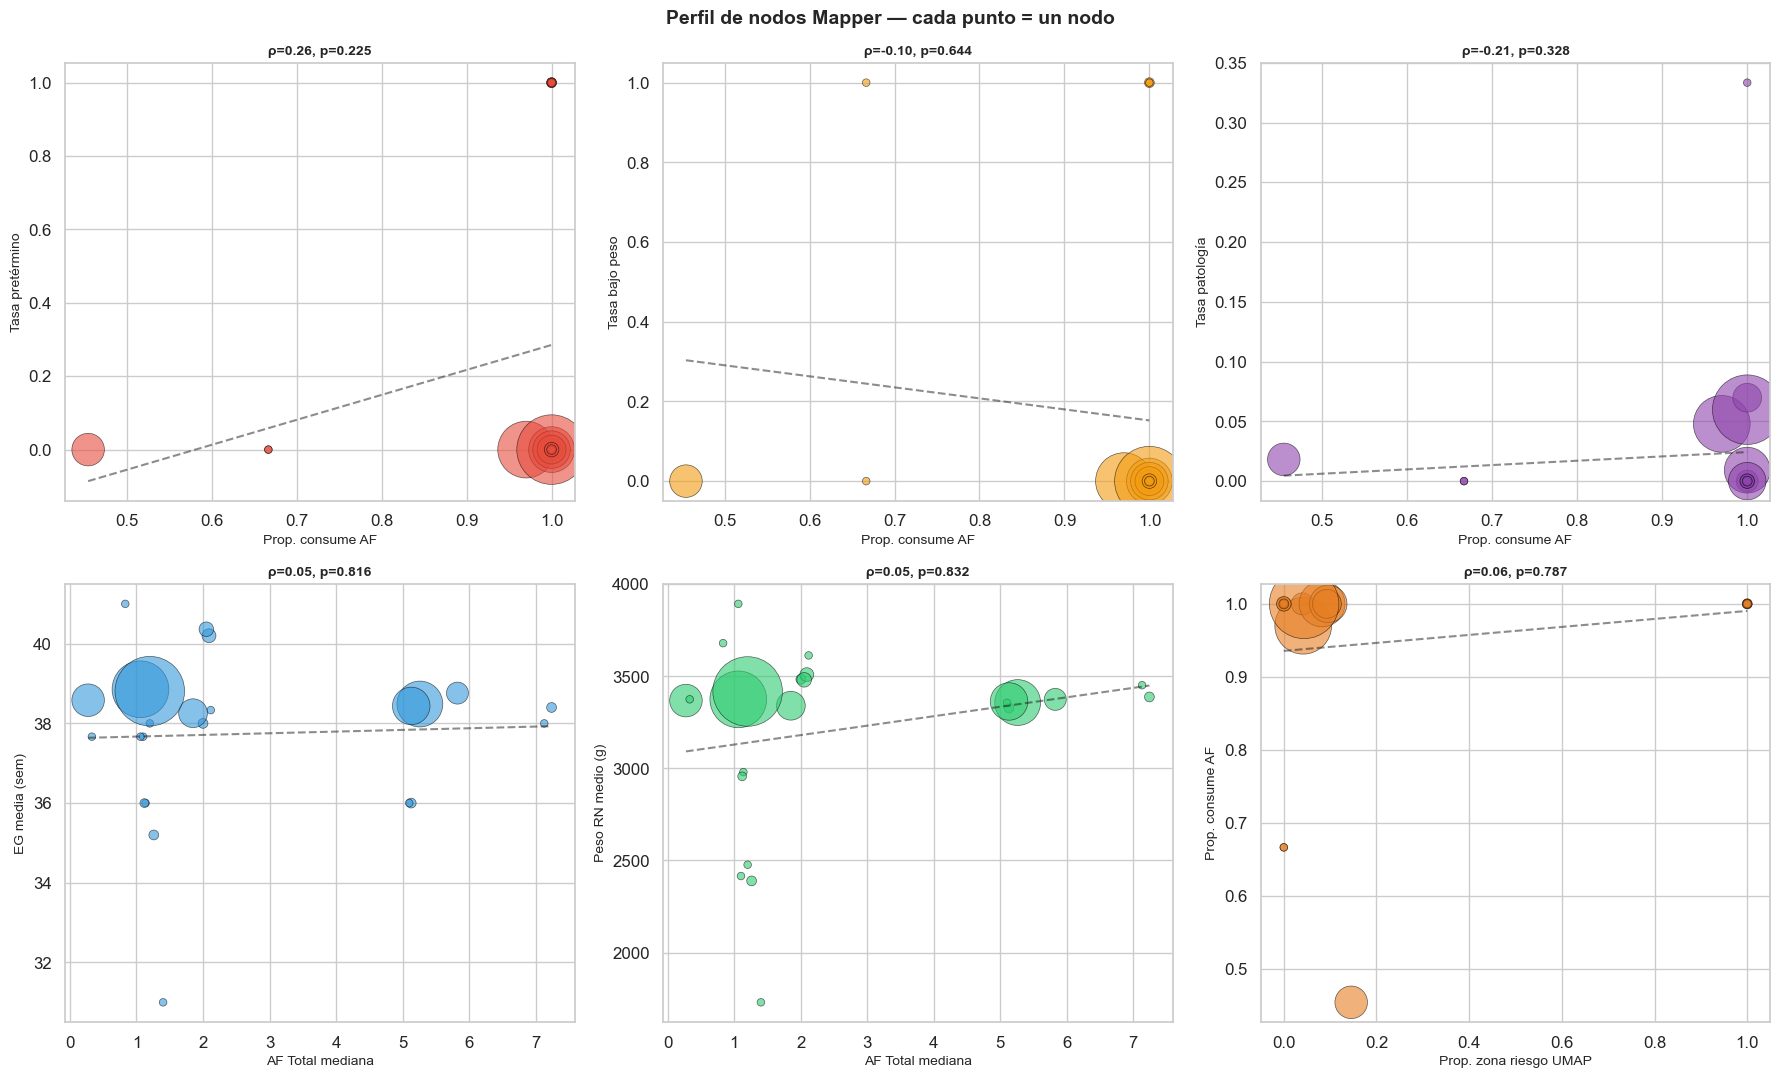

NODOS CON MENOR PROPORCIÓN DE CONSUMO AF

  Nodo cube0_cluster0 (n=55)
    Consume AF:  45%
    EG media:    38.6 sem
    PN medio:    3368 g
    Pretérmino:  0%
    Bajo peso:   0%
    Zona riesgo: 15%

  Nodo cube0_cluster1 (n=3)
    Consume AF:  67%
    EG media:    37.7 sem
    PN medio:    3375 g
    Pretérmino:  0%
    Bajo peso:   0%
    Zona riesgo: 0%

  Nodo cube1_cluster1 (n=3)
    Consume AF:  67%
    EG media:    37.7 sem
    PN medio:    2416 g
    Pretérmino:  0%
    Bajo peso:   100%
    Zona riesgo: 0%

  Nodo cube1_cluster0 (n=167)
    Consume AF:  97%
    EG media:    38.9 sem
    PN medio:    3375 g
    Pretérmino:  0%
    Bajo peso:   0%
    Zona riesgo: 4%

  Nodo cube11_cluster0 (n=25)
    Consume AF:  100%
    EG media:    38.8 sem
    PN medio:    3375 g
    Pretérmino:  0%
    Bajo peso:   0%
    Zona riesgo: 4%

NODOS CON MAYOR PROPORCIÓN DE CONSUMO AF

  Nodo cube11_cluster0 (n=25)
    Consume AF:  100%
    EG media:    38.8 sem
    PN medio:    3375 g
    P

In [20]:
# %%
# ── Análisis de todos los nodos Mapper ───────────────────────────────────
node_profiles = []
for nid, mids in graph_af_1d["nodes"].items():
    sub = df.iloc[mids]
    node_profiles.append({
        "nodo": nid,
        "n": len(mids),
        "EG_media": sub["EG hijo (sem)"].mean(),
        "PN_medio": sub["PN hijo (g)"].mean(),
        "AF_total_med": sub["Total mg/d AF  suple y pan"].median(),
        "prop_consume_af": sub["consume_af"].mean(),
        "tasa_preterm": sub["pretermino"].mean(),
        "tasa_bp": sub["bajo_peso"].mean(),
        "tasa_pat": sub["hijo_con_patologia"].mean(),
        "edad_media": sub["Edad madre"].mean(),
        "imc_pre_media": sub["IMC antes"].mean(),
        "prop_zona_riesgo": sub["zona_riesgo_umap"].mean(),
    })

ndf = pd.DataFrame(node_profiles).sort_values("prop_consume_af")

print(f"Total nodos: {len(ndf)}")
print(f"Tamaño nodos: min={ndf['n'].min()}, max={ndf['n'].max()}, mediana={ndf['n'].median():.0f}")
print()
print(ndf.to_string(index=False, float_format="%.2f"))

# %%
# ── Visualización: scatter matrix de nodos ───────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Perfil de nodos Mapper — cada punto = un nodo",
             fontsize=14, fontweight="bold")

plots = [
    ("prop_consume_af", "tasa_preterm", "Prop. consume AF", "Tasa pretérmino", "#e74c3c"),
    ("prop_consume_af", "tasa_bp", "Prop. consume AF", "Tasa bajo peso", "#f39c12"),
    ("prop_consume_af", "tasa_pat", "Prop. consume AF", "Tasa patología", "#8e44ad"),
    ("AF_total_med", "EG_media", "AF Total mediana", "EG media (sem)", "#3498db"),
    ("AF_total_med", "PN_medio", "AF Total mediana", "Peso RN medio (g)", "#2ecc71"),
    ("prop_zona_riesgo", "prop_consume_af", "Prop. zona riesgo UMAP", "Prop. consume AF", "#e67e22"),
]

for ax, (xvar, yvar, xlabel, ylabel, color) in zip(axes.flatten(), plots):
    sc = ax.scatter(ndf[xvar], ndf[yvar], s=ndf["n"] * 10,
                    c=color, alpha=0.6, edgecolors="black", linewidths=0.5)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)

    # Correlation
    mask = np.isfinite(ndf[xvar]) & np.isfinite(ndf[yvar])
    if mask.sum() > 3 and ndf.loc[mask, xvar].std() > 0:
        rho, p = spearmanr(ndf.loc[mask, xvar], ndf.loc[mask, yvar])
        z = np.polyfit(ndf.loc[mask, xvar], ndf.loc[mask, yvar], 1)
        xline = np.linspace(ndf[xvar].min(), ndf[xvar].max(), 50)
        ax.plot(xline, np.polyval(z, xline), "k--", lw=1.5, alpha=0.5)
        ax.set_title(f"ρ={rho:.2f}, p={p:.3f}", fontsize=10, fontweight="bold")
    else:
        ax.set_title("(sin variación)", fontsize=10)

plt.tight_layout()
plt.show()

# %%
# ── Nodos extremos: los de mayor y menor consumo AF ─────────────────────
print("=" * 70)
print("NODOS CON MENOR PROPORCIÓN DE CONSUMO AF")
print("=" * 70)
low_af = ndf.nsmallest(5, "prop_consume_af")
for _, row in low_af.iterrows():
    print(f"\n  Nodo {row['nodo']} (n={int(row['n'])})")
    print(f"    Consume AF:  {row['prop_consume_af']:.0%}")
    print(f"    EG media:    {row['EG_media']:.1f} sem")
    print(f"    PN medio:    {row['PN_medio']:.0f} g")
    print(f"    Pretérmino:  {row['tasa_preterm']:.0%}")
    print(f"    Bajo peso:   {row['tasa_bp']:.0%}")
    print(f"    Zona riesgo: {row['prop_zona_riesgo']:.0%}")

print("\n" + "=" * 70)
print("NODOS CON MAYOR PROPORCIÓN DE CONSUMO AF")
print("=" * 70)
high_af = ndf.nlargest(5, "prop_consume_af")
for _, row in high_af.iterrows():
    print(f"\n  Nodo {row['nodo']} (n={int(row['n'])})")
    print(f"    Consume AF:  {row['prop_consume_af']:.0%}")
    print(f"    EG media:    {row['EG_media']:.1f} sem")
    print(f"    PN medio:    {row['PN_medio']:.0f} g")
    print(f"    Pretérmino:  {row['tasa_preterm']:.0%}")
    print(f"    Bajo peso:   {row['tasa_bp']:.0%}")
    print(f"    Zona riesgo: {row['prop_zona_riesgo']:.0%}")
